In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from numpy import random as rn
from scipy import stats
import scipy.stats as si
import seaborn as sns
from scipy.stats import norm

import pandas as pd
cpi = pd.read_csv('tesla.csv')
cpi.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


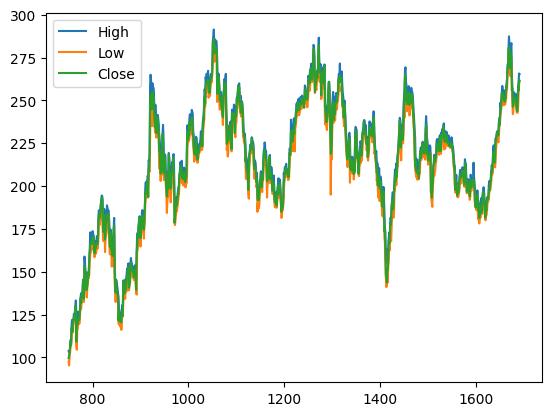

In [3]:
start = 750
stop  = len(cpi)
plt.plot(np.arange(start,stop),cpi['High'][start:stop],'-',label='High')
plt.plot(np.arange(start,stop),cpi['Low'][start:stop],'-',label='Low')
plt.plot(np.arange(start,stop),cpi['Close'][start:stop],'-',label='Close')
plt.legend()
plt.show()

In [4]:
cpi.tail()

,Date,Open,High,Low,Close,Volume,Adj Close
1687,3/13/2017,244.820007,246.850006,242.779999,246.169998,3010700,246.169998
1688,3/14/2017,246.110001,258.119995,246.020004,258.000000,7575500,258.000000
1689,3/15/2017,257.000000,261.000000,254.270004,255.729996,4816600,255.729996
1690,3/16/2017,262.399994,265.750000,259.059998,262.049988,7100400,262.049988
1691,3/17/2017,264.000000,265.329987,261.200012,261.500000,6475900,261.500000


In [5]:
a = 0.015
b = 0.001
df = cpi.copy()
# df = df.rename(columns={"Close": "S"})
df = df.drop(columns=['Open','High','Low','Volume','Adj Close'])
df.head()

,Date,Close
0,6/29/2010,23.889999
1,6/30/2010,23.830000
2,7/1/2010,21.959999
3,7/2/2010,19.200001
4,7/6/2010,16.110001


Original DataFrame:
           Date       Close       date
0     6/29/2010   23.889999 2010-06-29
1     6/30/2010   23.830000 2010-06-30
2      7/1/2010   21.959999 2010-07-01
3      7/2/2010   19.200001 2010-07-02
4      7/6/2010   16.110001 2010-07-06
...         ...         ...        ...
1687  3/13/2017  246.169998 2017-03-13
1688  3/14/2017  258.000000 2017-03-14
1689  3/15/2017  255.729996 2017-03-15
1690  3/16/2017  262.049988 2017-03-16
1691  3/17/2017  261.500000 2017-03-17

[1692 rows x 3 columns]

Filtered DataFrame (year > 2013):
           Date       Close       date
1136   1/2/2015  219.309998 2015-01-02
1137   1/5/2015  210.089996 2015-01-05
1138   1/6/2015  211.279999 2015-01-06
1139   1/7/2015  210.949997 2015-01-07
1140   1/8/2015  210.619995 2015-01-08
...         ...         ...        ...
1687  3/13/2017  246.169998 2017-03-13
1688  3/14/2017  258.000000 2017-03-14
1689  3/15/2017  255.729996 2017-03-15
1690  3/16/2017  262.049988 2017-03-16
1691  3/17/2017  261.50

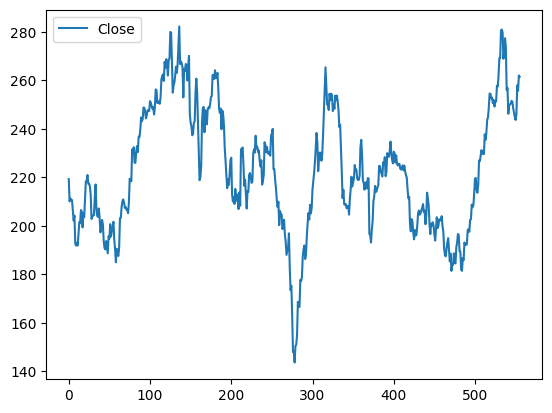

In [6]:
# 1. Convert the 'date_str' column to datetime
df['date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
# 2. Filter rows where the year is greater than 2013
filtered_df = df[df['date'].dt.year >= 2015]

print("Original DataFrame:")
print(df)
print("\nFiltered DataFrame (year > 2013):")
print(filtered_df)
plt.plot(np.arange(len(filtered_df)),filtered_df['Close'],'-',label='Close')
plt.legend()
plt.show()

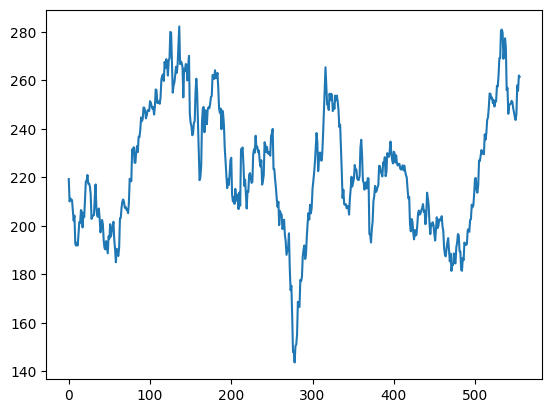

c:\Users\Acer\dudee-venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch [5/50], Loss: -0.293690
Epoch [10/50], Loss: -2.246367
Epoch [15/50], Loss: -2.270724
Epoch [20/50], Loss: -2.262186
Epoch [25/50], Loss: -2.196166
Epoch [30/50], Loss: -2.295926
Epoch [35/50], Loss: -2.283734
Epoch [40/50], Loss: -2.303499
Epoch [45/50], Loss: -2.310267
Epoch [50/50], Loss: -2.299148
Predicted mu for next day: -0.0163
Predicted sigma for next day: 0.0244
Predicted next price (mean): 257.2057


In [7]:
import torch
import torch.nn as nn
import numpy as np

# -----------------------
# 1) เตรียมข้อมูล
# -----------------------

# สมมติ prices เป็น numpy array (T x 1)
# ตัวอย่างเช่น
# prices = np.array([...])

prices = filtered_df['Close'].values  # ตัวอย่างสมมติ
T = len(prices)
plt.plot(np.arange(T),prices)
plt.show()
# คำนวณ log-returns
returns = np.log(prices[1:] / prices[:-1])  # shape (T-1,)

# สร้าง feature/label
n_lag = 3  # จำนวนวันย้อนหลังที่ใช้เป็น feature
X = []
y = []  # y จะเก็บ (r_t) ของวันถัดไป เพื่อเทียบกับ (mu_t - 0.5*sigma^2) ได้
for i in range(n_lag, len(returns)):
    X.append(returns[i-n_lag:i])       # returns ย้อนหลัง n_lag วัน
    y.append(returns[i])              # return ของวันถัดไป (target)

X = np.array(X)  # shape: (N, n_lag)
y = np.array(y)  # shape: (N,)

X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).float()

# ถ้าจะทำ DataLoader สามารถทำได้ แต่ตัวอย่างนี้จะ train ทั้งหมดรวดเดียว
dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

# -----------------------
# 2) สร้างโมเดล (MLP) 
#    เพื่อให้ออก mu, sigma
# -----------------------
class MLPGBM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super(MLPGBM, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        # layer สำหรับปรับไปเป็น mu และ log_sigma
        self.mu_layer = nn.Linear(hidden_dim, 1)
        self.log_sigma_layer = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        h = self.net(x)
        mu = self.mu_layer(h)          # shape: (batch_size, 1)
        log_sigma = self.log_sigma_layer(h)  # shape: (batch_size, 1)
        sigma = torch.exp(log_sigma)   # บังคับ sigma > 0
        return mu.squeeze(-1), sigma.squeeze(-1)
    
model = MLPGBM(input_dim=n_lag)

# -----------------------
# 3) นิยาม Optimizer
# -----------------------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -----------------------
# 4) นิยาม Loss Function (NLL)
# -----------------------
def gbm_nll_loss(mu, sigma, r):
    """
    mu, sigma: shape (batch_size,)
    r: log-return จริงของวันถัดไป (batch_size,)
    
    จาก r_t ~ N(mu_t - 0.5*sigma_t^2, sigma_t^2)
    แต่ในที่นี้อาจจะสรุปว่าเราพยายามทำนาย "mean" ของ r_t = mu_t_pred (ทีเดียว)
    แล้ว adopt เข้าไปว่า mean จริง ๆ = mu_t - 0.5*sigma_t^2
    """
    # ถ้าต้องการแบบเป๊ะ ๆ ตาม GBM ควรแก้เป็น
    # mean = mu - 0.5 * sigma**2
    # แต่ในที่นี้ขอสมมติง่าย ๆ ว่า neural network output = mean ตรง ๆ ก่อน
    # ถ้าจะให้ตรง GBM จริง ๆ ก็แก้ code ด้านล่างเป็น:
    mean = mu - 0.5 * sigma**2
    
    # negative log-likelihood ของ Normal(mean, sigma^2)
    # NLL = 0.5 * log(2*pi*sigma^2) + ((r - mean)^2) / (2*sigma^2)
    # (drop constant terms บางส่วนไปได้)
    
    # เพื่อความสมบูรณ์ลองเขียนเต็ม ๆ:
    nll = 0.5 * torch.log(2 * torch.pi * sigma**2) + (r - mean)**2 / (2 * sigma**2)
    return nll.mean()

# -----------------------
# 5) Train Loop
# -----------------------
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    
    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()
        
        # forward
        mu_pred, sigma_pred = model(batch_x)
        loss = gbm_nll_loss(mu_pred, sigma_pred, batch_y)
        
        # backward
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch_x.size(0)
    
    total_loss /= len(dataset)
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.6f}")

# -----------------------
# 6) การทำนาย (Inference)
# -----------------------
model.eval()
with torch.no_grad():
    # สมมติจะทำนายวันถัดไป ใช้ return ย้อนหลัง n_lag วันล่าสุด
    recent_returns = returns[-n_lag:]
    x_infer = torch.from_numpy(recent_returns).float().unsqueeze(0)  # shape (1, n_lag)
    
    mu_hat, sigma_hat = model(x_infer)
    mu_hat, sigma_hat = mu_hat.item(), sigma_hat.item()
    
    print(f"Predicted mu for next day: {mu_hat:.4f}")
    print(f"Predicted sigma for next day: {sigma_hat:.4f}")
    
    # หากอยากได้ราคาถัดไปตาม GBM:
    # S_{t+1} = S_t exp((mu - 0.5 sigma^2) + sigma * eps)
    # อาจจะจำลองหลายๆ eps เพื่อดู distribution หรือใช้ค่า mean ทำนาย
    S_t = prices[-1]
    mean_return = mu_hat - 0.5 * (sigma_hat**2)
    # ค่ากลางของ S_{t+1}:
    S_next = S_t * np.exp(mean_return)
    print(f"Predicted next price (mean): {S_next:.4f}")


Epoch [1/50] - Loss: -1.094426
Epoch [10/50] - Loss: -1.941833
Epoch [20/50] - Loss: -1.939846
Epoch [30/50] - Loss: -1.934500
Epoch [40/50] - Loss: -1.925648
Epoch [50/50] - Loss: -1.945498


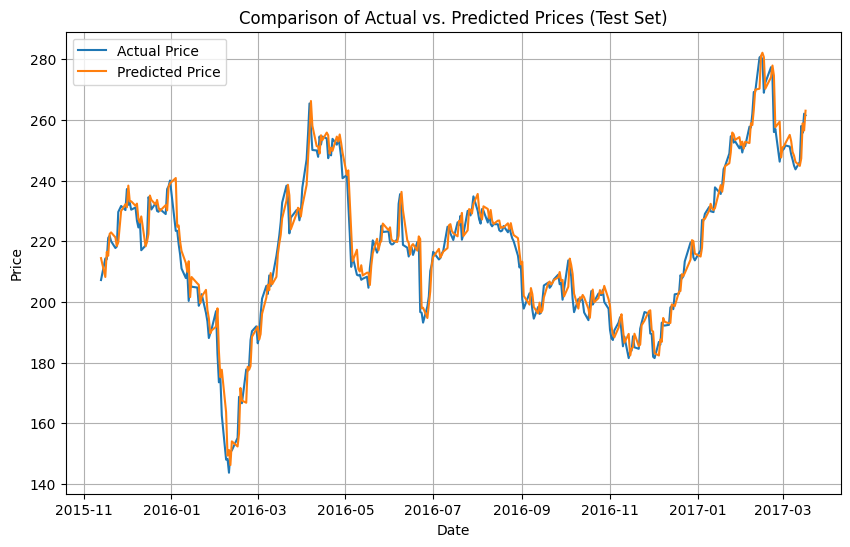

Test RMSE: 5.1372


In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------------
# 1) เตรียมข้อมูลตัวอย่าง (df) สมมติว่ามีคอลัมน์ "date" และ "Close"
# --------------------------------------------------------------------------------
# ตัวอย่างสมมติ: สร้างข้อมูลเล่น ๆ 30 วัน
np.random.seed(42)
# data_size = 30
# data = {
#     "date": pd.date_range(start="2015-01-02", periods=data_size, freq="D"),
#     "Close": np.random.uniform(200, 300, data_size)
# }
# df = pd.DataFrame(data)

# # เรียงตามวันที่ และ reset index
# df.sort_values(by="date", inplace=True)
# df.reset_index(drop=True, inplace=True)

# --------------------------------------------------------------------------------
# 2) คำนวณ log-returns
# --------------------------------------------------------------------------------
prices = df["Close"].values  # numpy array
T = len(prices)

if T < 2:
    raise ValueError("ข้อมูลน้อยเกินไป ไม่สามารถคำนวณ log-return ได้")

# returns[i] = log( Close[i+1] / Close[i] )
returns = np.log(prices[1:] / prices[:-1])  # shape: (T-1,)

# --------------------------------------------------------------------------------
# 3) สร้าง (X, y) ด้วยการใช้ n_lag วันย้อนหลัง
#    และเก็บ index เพื่อจะได้รู้ว่าตัวอย่างไหนคือวันไหน
# --------------------------------------------------------------------------------
n_lag = 7
X_list = []
y_list = []
idx_list = []  # เอาไว้เก็บว่า sample นี้ตรงกับ returns ของวัน i

for i in range(n_lag, len(returns)):
    # X = [r_{i-n_lag}, ..., r_{i-1}]
    X_list.append(returns[i-n_lag:i])
    # y = r_i
    y_list.append(returns[i])
    # เก็บ index ของตัวอย่าง i ไว้ (จะสื่อว่าเป็น log-return ของวัน i)
    idx_list.append(i)

X = np.array(X_list)  # shape (N, n_lag)
y = np.array(y_list)  # shape (N,)
idx_array = np.array(idx_list)  # เก็บ mapping กลับไปยังวัน/ราคา

# --------------------------------------------------------------------------------
# 4) แบ่ง Train/Test
# --------------------------------------------------------------------------------
train_ratio = 0.8
train_size = int(train_ratio * len(X))

X_train = X[:train_size]
y_train = y[:train_size]
idx_train = idx_array[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]
idx_test = idx_array[train_size:]

# --------------------------------------------------------------------------------
# 5) สร้าง PyTorch Dataset & DataLoader
# --------------------------------------------------------------------------------
class ReturnsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ReturnsDataset(X_train, y_train)
test_dataset = ReturnsDataset(X_test, y_test)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# (test_loader ไว้ดูตัวอย่าง หรือจะ infer ทีละ batch ก็ได้
#  แต่ในที่นี้เดี๋ยวเราจะ predict ทีเดียวแบบ bulk)

# --------------------------------------------------------------------------------
# 6) สร้างโมเดล MLPGBM ทำนาย mu และ sigma
# --------------------------------------------------------------------------------
class MLPGBM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super(MLPGBM, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.mu_layer = nn.Linear(hidden_dim, 1)
        self.log_sigma_layer = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        # x: (batch_size, input_dim)
        h = self.net(x)
        mu = self.mu_layer(h).squeeze(-1)           # (batch_size,)
        log_sigma = self.log_sigma_layer(h).squeeze(-1)  # (batch_size,)
        sigma = torch.exp(log_sigma)                # บังคับให้ sigma > 0
        return mu, sigma

model = MLPGBM(input_dim=n_lag, hidden_dim=32)

# --------------------------------------------------------------------------------
# 7) Loss function (Negative Log-Likelihood) และ Optimizer
# --------------------------------------------------------------------------------
def gbm_nll_loss(mu, sigma, r):
    """
    r ~ Normal( mean = mu - 0.5*sigma^2, var = sigma^2 )
    """
    mean = mu - 0.5 * (sigma ** 2)
    # NLL = 0.5 * log(2*pi*sigma^2) + (r - mean)^2 / (2*sigma^2)
    nll = 0.5 * torch.log(2 * torch.pi * sigma**2) + ((r - mean)**2) / (2 * sigma**2)
    return nll.mean()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# --------------------------------------------------------------------------------
# 8) Train Model
# --------------------------------------------------------------------------------
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        
        mu_pred, sigma_pred = model(batch_x)
        loss = gbm_nll_loss(mu_pred, sigma_pred, batch_y)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_x.size(0)
    
    epoch_loss /= len(train_dataset)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.6f}")

# --------------------------------------------------------------------------------
# 9) ทดสอบโมเดล (Inference) กับ Test set
#    เราจะทำนายราคาวันถัดไป เทียบกับราคาจริง
# --------------------------------------------------------------------------------
model.eval()

# สร้าง tensor สำหรับ X_test
X_test_torch = torch.from_numpy(X_test).float()

with torch.no_grad():
    mu_test, sigma_test = model(X_test_torch)
    mu_test = mu_test.numpy()
    sigma_test = sigma_test.numpy()

# --------------------------------------------------------------------------------
# 10) แปลง mu, sigma => ราคาที่ทำนาย
#     สมมติว่า sample i ใน X_test ตรงกับ returns[idx_test[i]]
#     นั่นหมายถึงเป็น log-return ระหว่าง S[idx_test[i]] และ S[idx_test[i]+1]
#     ดังนั้นเราจะทำนาย S_{idx_test[i]+1}
# --------------------------------------------------------------------------------

pred_prices = []
true_prices = []
test_dates = []

for i in range(len(X_test)):
    # index ของ returns: idx_test[i]
    # returns[idx_test[i]] = log( prices[idx_test[i]+1] / prices[idx_test[i]] )
    # ราคาจริงของวัน "idx_test[i]" คือ prices[idx_test[i]]
    # ราคาจริงของวันถัดไป (ที่จะเทียบ) คือ prices[idx_test[i] + 1]
    current_price = prices[idx_test[i]]       # S_t
    true_next_price = prices[idx_test[i] + 1] # S_{t+1} (ของจริง)
    
    # คำนวณ mean_return จาก mu, sigma
    mu_i = mu_test[i]
    sigma_i = sigma_test[i]
    mean_return = mu_i - 0.5 * (sigma_i**2)
    
    # ทำนายราคาถัดไป (ค่าเฉลี่ย)
    pred_next_price = current_price * np.exp(mean_return)
    
    pred_prices.append(pred_next_price)
    true_prices.append(true_next_price)
    
    # เก็บวันที่ "ของวันถัดไป" ไว้เป็นหมุดบนแกน x
    # สมมติ index = idx_test[i] => วันนั้นคือ df["date"][ idx_test[i] ]
    # เราอยาก plot กับวันถัดไป => df["date"][ idx_test[i] + 1 ]
    next_day_date = df["date"].iloc[idx_test[i] + 1]
    test_dates.append(next_day_date)

pred_prices = np.array(pred_prices)
true_prices = np.array(true_prices)
test_dates = pd.to_datetime(test_dates)  # list of Timestamps

# --------------------------------------------------------------------------------
# 11) Visualize
# --------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.title("Comparison of Actual vs. Predicted Prices (Test Set)")
plt.plot(test_dates, true_prices,'-', label="Actual Price")
plt.plot(test_dates, pred_prices,'-', label="Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# นอกจากนี้ ถ้าอยากดู performance metrics เชิงตัวเลข
# เช่น RMSE หรือ MAPE ก็สามารถคำนวณเพิ่มเติมได้
rmse = np.sqrt(np.mean((pred_prices - true_prices)**2))
print(f"Test RMSE: {rmse:.4f}")


In [9]:
import yfinance as yf
data = yf.download("AAPL", start="2017-01-01", end="2023-12-30")
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2017-01-03,26.891958,26.933633,26.570135,26.810924,115127600
2017-01-04,26.861860,26.975310,26.799349,26.822501,84472400
2017-01-05,26.998463,27.056345,26.813240,26.838708,88774400
2017-01-06,27.299448,27.357330,26.966047,27.037820,127007600
2017-01-09,27.549501,27.651374,27.306398,27.308712,134247600
...,...,...,...,...,...
2023-12-22,192.656174,194.457347,192.029240,194.228458,37122800
2023-12-26,192.108856,192.944757,191.889928,192.666124,28919300


[*********************100%***********************]  1 of 1 completed


Epoch [1/200] - Loss: 1.092598
Epoch [10/200] - Loss: -1.768925
Epoch [20/200] - Loss: -2.252948
Epoch [30/200] - Loss: -2.339298
Epoch [40/200] - Loss: -2.408064
Epoch [50/200] - Loss: -2.416651
Epoch [60/200] - Loss: -2.452657
Epoch [70/200] - Loss: -2.477498
Epoch [80/200] - Loss: -2.507425
Epoch [90/200] - Loss: -2.524115
Epoch [100/200] - Loss: -2.533144
Epoch [110/200] - Loss: -2.536071
Epoch [120/200] - Loss: -2.539471
Epoch [130/200] - Loss: -2.527626
Epoch [140/200] - Loss: -2.542897
Epoch [150/200] - Loss: -2.515482
Epoch [160/200] - Loss: -2.524768
Epoch [170/200] - Loss: -2.558666
Epoch [180/200] - Loss: -2.564947
Epoch [190/200] - Loss: -2.538480
Epoch [200/200] - Loss: -2.550728


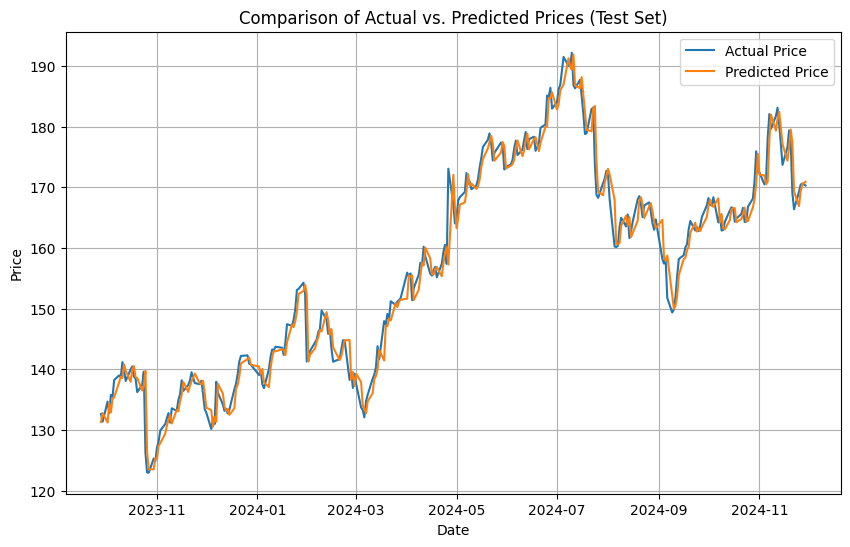

Test RMSE: 2.6946


In [50]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import yfinance as yf
data = yf.download("GOOG", start="2019-01-01", end="2024-12-01")
# --------------------------------------------------------------------------------
# 1) เตรียมข้อมูลตัวอย่าง (df) สมมติว่ามีคอลัมน์ "date" และ "Close"
# --------------------------------------------------------------------------------
# ตัวอย่างสมมติ: สร้างข้อมูลเล่น ๆ 30 วัน
np.random.seed(42)


# --------------------------------------------------------------------------------
# 2) คำนวณ log-returns
# --------------------------------------------------------------------------------
df = data.copy()
prices = df["Close"].values  # numpy array
prices = prices.reshape(-1)
T = len(prices)

if T < 2:
    raise ValueError("ข้อมูลน้อยเกินไป ไม่สามารถคำนวณ log-return ได้")

# returns[i] = log( Close[i+1] / Close[i] )
returns = np.log(prices[1:] / prices[:-1])  # shape: (T-1,)

# --------------------------------------------------------------------------------
# 3) สร้าง (X, y) ด้วยการใช้ n_lag วันย้อนหลัง
#    และเก็บ index เพื่อจะได้รู้ว่าตัวอย่างไหนคือวันไหน
# --------------------------------------------------------------------------------
n_lag = 8
X_list = []
y_list = []
idx_list = []  # เอาไว้เก็บว่า sample นี้ตรงกับ returns ของวัน i

for i in range(n_lag, len(returns)):
    # X = [r_{i-n_lag}, ..., r_{i-1}]
    X_list.append(returns[i-n_lag:i])
    # y = r_i
    y_list.append(returns[i])
    # เก็บ index ของตัวอย่าง i ไว้ (จะสื่อว่าเป็น log-return ของวัน i)
    idx_list.append(i)

X = np.array(X_list)  # shape (N, n_lag)
y = np.array(y_list)  # shape (N,)
idx_array = np.array(idx_list)  # เก็บ mapping กลับไปยังวัน/ราคา

# --------------------------------------------------------------------------------
# 4) แบ่ง Train/Test
# --------------------------------------------------------------------------------
train_ratio = 0.8
train_size = int(train_ratio * len(X))

X_train = X[:train_size]
y_train = y[:train_size]
idx_train = idx_array[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]
idx_test = idx_array[train_size:]

# --------------------------------------------------------------------------------
# 5) สร้าง PyTorch Dataset & DataLoader
# --------------------------------------------------------------------------------
class ReturnsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ReturnsDataset(X_train, y_train)
test_dataset = ReturnsDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# (test_loader ไว้ดูตัวอย่าง หรือจะ infer ทีละ batch ก็ได้
#  แต่ในที่นี้เดี๋ยวเราจะ predict ทีเดียวแบบ bulk)

# --------------------------------------------------------------------------------
# 6) สร้างโมเดล MLPGBM ทำนาย mu และ sigma
# --------------------------------------------------------------------------------
class MLPGBM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super(MLPGBM, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.1),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.1),
            nn.Sigmoid(),
            nn.Linear(hidden_dim,2)
        )
        # self.mu_layer = nn.Linear(hidden_dim, 1)
        # self.log_sigma_layer = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        # x: (batch_size, input_dim)
        result = self.net(x)
        # mu = self.mu_layer(h).squeeze(-1)           # (batch_size,)
        # log_sigma = self.log_sigma_layer(h).squeeze(-1)  # (batch_size,)
        mu,sigma = result[:,0],torch.exp(result[:,1])                # บังคับให้ sigma > 0
        return mu, sigma

model = MLPGBM(input_dim=n_lag, hidden_dim=16)

# --------------------------------------------------------------------------------
# 7) Loss function (Negative Log-Likelihood) และ Optimizer
# --------------------------------------------------------------------------------
def gbm_nll_loss(mu, sigma, r):
    """
    r ~ Normal( mean = mu - 0.5*sigma^2, var = sigma^2 )
    """
    mean = mu - 0.5 * (sigma ** 2)
    # NLL = 0.5 * log(2*pi*sigma^2) + (r - mean)^2 / (2*sigma^2)
    nll = 0.5 * torch.log(2 * torch.pi * sigma**2) + ((r - mean)**2) / (2 * sigma**2)
    return nll.mean()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# --------------------------------------------------------------------------------
# 8) Train Model
# --------------------------------------------------------------------------------
num_epochs = 200

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        mu_pred, sigma_pred = model(batch_x)
        loss = gbm_nll_loss(mu_pred, sigma_pred, batch_y)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_x.size(0)
    
    epoch_loss /= len(train_dataset)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.6f}")

# --------------------------------------------------------------------------------
# 9) ทดสอบโมเดล (Inference) กับ Test set
#    เราจะทำนายราคาวันถัดไป เทียบกับราคาจริง
# --------------------------------------------------------------------------------
model.eval()

# สร้าง tensor สำหรับ X_test
X_test_torch = torch.from_numpy(X_test).float()

with torch.no_grad():
    mu_test, sigma_test = model(X_test_torch)
    mu_test = mu_test.numpy()
    sigma_test = sigma_test.numpy()

# --------------------------------------------------------------------------------
# 10) แปลง mu, sigma => ราคาที่ทำนาย
#     สมมติว่า sample i ใน X_test ตรงกับ returns[idx_test[i]]
#     นั่นหมายถึงเป็น log-return ระหว่าง S[idx_test[i]] และ S[idx_test[i]+1]
#     ดังนั้นเราจะทำนาย S_{idx_test[i]+1}
# --------------------------------------------------------------------------------

pred_prices = []
true_prices = []
test_dates = []

for i in range(len(X_test)):
    # index ของ returns: idx_test[i]
    # returns[idx_test[i]] = log( prices[idx_test[i]+1] / prices[idx_test[i]] )
    # ราคาจริงของวัน "idx_test[i]" คือ prices[idx_test[i]]
    # ราคาจริงของวันถัดไป (ที่จะเทียบ) คือ prices[idx_test[i] + 1]
    current_price = prices[idx_test[i]]       # S_t
    true_next_price = prices[idx_test[i] + 1] # S_{t+1} (ของจริง)
    
    # คำนวณ mean_return จาก mu, sigma
    mu_i = mu_test[i]
    sigma_i = sigma_test[i]
    mean_return = mu_i - 0.5 * (sigma_i**2)
    
    # ทำนายราคาถัดไป (ค่าเฉลี่ย)
    pred_next_price = current_price * np.exp(mean_return)
    
    pred_prices.append(pred_next_price)
    true_prices.append(true_next_price)
    
    # เก็บวันที่ "ของวันถัดไป" ไว้เป็นหมุดบนแกน x
    # สมมติ index = idx_test[i] => วันนั้นคือ df["date"][ idx_test[i] ]
    # เราอยาก plot กับวันถัดไป => df["date"][ idx_test[i] + 1 ]
    next_day_date = df.index[idx_test[i] + 1]
    test_dates.append(next_day_date)

pred_prices = np.array(pred_prices)
true_prices = np.array(true_prices)
test_dates = pd.to_datetime(test_dates)  # list of Timestamps

# --------------------------------------------------------------------------------
# 11) Visualize
# --------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.title("Comparison of Actual vs. Predicted Prices (Test Set)")
plt.plot(test_dates, true_prices,'-', label="Actual Price")
plt.plot(test_dates, pred_prices,'-', label="Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# นอกจากนี้ ถ้าอยากดู performance metrics เชิงตัวเลข
# เช่น RMSE หรือ MAPE ก็สามารถคำนวณเพิ่มเติมได้
rmse = np.sqrt(np.mean((pred_prices - true_prices)**2))
print(f"Test RMSE: {rmse:.4f}")


[*********************100%***********************]  1 of 1 completed

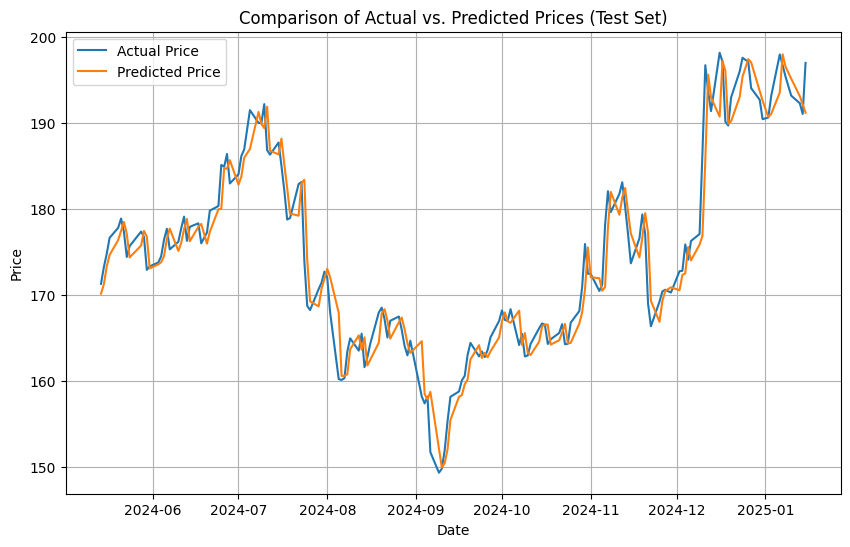

Test RMSE: 2.8721


In [51]:
import yfinance as yf
data = yf.download("GOOG", start="2024-05-01", end="2025-01-16")
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------------
# 1) เตรียมข้อมูลตัวอย่าง (df) สมมติว่ามีคอลัมน์ "date" และ "Close"
# --------------------------------------------------------------------------------
# ตัวอย่างสมมติ: สร้างข้อมูลเล่น ๆ 30 วัน
np.random.seed(42)
# data_size = 30
# data = {
#     "date": pd.date_range(start="2015-01-02", periods=data_size, freq="D"),
#     "Close": np.random.uniform(200, 300, data_size)
# }
# df = pd.DataFrame(data)

# # เรียงตามวันที่ และ reset index
# df.sort_values(by="date", inplace=True)
# df.reset_index(drop=True, inplace=True)

# --------------------------------------------------------------------------------
# 2) คำนวณ log-returns
# --------------------------------------------------------------------------------
df = data.copy()
prices = df["Close"].values  # numpy array
prices = prices.reshape(-1)
T = len(prices)

if T < 2:
    raise ValueError("ข้อมูลน้อยเกินไป ไม่สามารถคำนวณ log-return ได้")

# returns[i] = log( Close[i+1] / Close[i] )
returns = np.log(prices[1:] / prices[:-1])  # shape: (T-1,)

# --------------------------------------------------------------------------------
# 3) สร้าง (X, y) ด้วยการใช้ n_lag วันย้อนหลัง
#    และเก็บ index เพื่อจะได้รู้ว่าตัวอย่างไหนคือวันไหน
# --------------------------------------------------------------------------------
# n_lag = 2
X_list = []
y_list = []
idx_list = []  # เอาไว้เก็บว่า sample นี้ตรงกับ returns ของวัน i

for i in range(n_lag, len(returns)):
    # X = [r_{i-n_lag}, ..., r_{i-1}]
    X_list.append(returns[i-n_lag:i])
    # y = r_i
    y_list.append(returns[i])
    # เก็บ index ของตัวอย่าง i ไว้ (จะสื่อว่าเป็น log-return ของวัน i)
    idx_list.append(i)

X = np.array(X_list)  # shape (N, n_lag)
y = np.array(y_list)  # shape (N,)
idx_array = np.array(idx_list)  # เก็บ mapping กลับไปยังวัน/ราคา

X_test = X
y_test = y
idx_test = idx_array

test_dataset = ReturnsDataset(X_test, y_test)

model.eval()

# สร้าง tensor สำหรับ X_test
X_test_torch = torch.from_numpy(X_test).float()

with torch.no_grad():
    mu_test, sigma_test = model(X_test_torch)
    mu_test = mu_test.numpy()
    sigma_test = sigma_test.numpy()

pred_prices = []
true_prices = []
test_dates = []

for i in range(len(X_test)):
    current_price = prices[idx_test[i]]       # S_t
    true_next_price = prices[idx_test[i] + 1] # S_{t+1} (ของจริง)
    
    # คำนวณ mean_return จาก mu, sigma
    mu_i = mu_test[i]
    sigma_i = sigma_test[i]
    mean_return = mu_i - 0.5 * (sigma_i**2)
    
    # ทำนายราคาถัดไป (ค่าเฉลี่ย)
    pred_next_price = current_price * np.exp(mean_return)
    
    pred_prices.append(pred_next_price)
    true_prices.append(true_next_price)

    next_day_date = df.index[idx_test[i] + 1]
    test_dates.append(next_day_date)

pred_prices = np.array(pred_prices)
true_prices = np.array(true_prices)
test_dates = pd.to_datetime(test_dates)  # list of Timestamps

plt.figure(figsize=(10, 6))
plt.title("Comparison of Actual vs. Predicted Prices (Test Set)")
plt.plot(test_dates, true_prices,'-', label="Actual Price")
plt.plot(test_dates, pred_prices,'-', label="Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

rmse = np.sqrt(np.mean((pred_prices - true_prices)**2))
print(f"Test RMSE: {rmse:.4f}")


In [46]:
X

array([[ 0.01730427,  0.00314123],
       [ 0.00314123,  0.00495829],
       [ 0.00495829,  0.0183782 ],
       [ 0.0183782 , -0.01057723],
       [-0.01057723,  0.00245088],
       [ 0.00245088, -0.00754688],
       [-0.00754688,  0.00357574],
       [ 0.00357574,  0.00600888],
       [ 0.00600888,  0.01127802],
       [ 0.01127802,  0.00887469],
       [ 0.00887469,  0.01054657],
       [ 0.01054657,  0.0065778 ],
       [ 0.0065778 ,  0.0060335 ],
       [ 0.0060335 , -0.00861447],
       [-0.00861447, -0.01665478],
       [-0.01665478,  0.00722858],
       [ 0.00722858,  0.00953855],
       [ 0.00953855, -0.00348885],
       [-0.00348885, -0.02188369],
       [-0.02188369,  0.00230207],
       [ 0.00230207,  0.00264083],
       [ 0.00264083,  0.00406237],
       [ 0.00406237,  0.01101661],
       [ 0.01101661,  0.00720271],
       [ 0.00720271, -0.01354811],
       [-0.01354811,  0.00499457],
       [ 0.00499457,  0.00879333],
       [ 0.00879333,  0.00765896],
       [ 0.00765896,